In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,classification_report, make_scorer
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn import set_config

In [2]:
set_config(transform_output="pandas")

# Load the data

In [3]:
df =  pd.read_csv("../../data/hyper.csv")
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age,bmi,bp_category,bp_enconded
0,M,168,62.0,110,80,1,1,0,0,1,50,21.967120,Hypertension Stage 1,1
1,F,156,85.0,140,90,3,1,0,0,1,55,34.927679,Hypertension Stage 2,2
2,F,165,64.0,130,70,3,1,0,0,0,51,23.507805,Hypertension Stage 1,1
3,M,169,82.0,150,100,1,1,0,0,1,48,28.710479,Hypertension Stage 2,2
4,F,156,56.0,100,60,1,1,0,0,0,47,23.011177,Normal,3


In [4]:
df['bp_binary'] = (df['bp_category'] != "Normal").astype(int)

In [5]:
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age,bmi,bp_category,bp_enconded,bp_binary
0,M,168,62.0,110,80,1,1,0,0,1,50,21.967120,Hypertension Stage 1,1,1
1,F,156,85.0,140,90,3,1,0,0,1,55,34.927679,Hypertension Stage 2,2,1
2,F,165,64.0,130,70,3,1,0,0,0,51,23.507805,Hypertension Stage 1,1,1
3,M,169,82.0,150,100,1,1,0,0,1,48,28.710479,Hypertension Stage 2,2,1
4,F,156,56.0,100,60,1,1,0,0,0,47,23.011177,Normal,3,0


In [6]:
df.drop(columns=['bp_category', 'bp_enconded','ap_hi','ap_lo'], axis =1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gender       68205 non-null  object 
 1   height       68205 non-null  int64  
 2   weight       68205 non-null  float64
 3   cholesterol  68205 non-null  int64  
 4   gluc         68205 non-null  int64  
 5   smoke        68205 non-null  int64  
 6   alco         68205 non-null  int64  
 7   active       68205 non-null  int64  
 8   age          68205 non-null  int64  
 9   bmi          68205 non-null  float64
 10  bp_binary    68205 non-null  int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 5.7+ MB


In [8]:
num_cols = ['height','weight', 'age','bmi']
ordinal_cols = ['cholesterol','gluc']
nominal_cols = ['gender','smoke','alco','active']


x = df.drop('bp_binary', axis=1)[num_cols+ordinal_cols+nominal_cols]
y = df['bp_binary']

X_train,X_test,Y_train,Y_test =  train_test_split(x,y , stratify=y , random_state= 42, test_size=0.2)

In [9]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape, sep="\n")

(54564, 10)
(54564,)
(13641, 10)
(13641,)


In [10]:
print(Y_test.value_counts(normalize=True))
print(Y_train.value_counts(normalize=True))

bp_binary
1    0.86196
0    0.13804
Name: proportion, dtype: float64
bp_binary
1    0.861924
0    0.138076
Name: proportion, dtype: float64


## Define categorical& num  transformer

In [11]:
num_preprocessor =  make_pipeline(
    SimpleImputer(strategy='median')
)

norminal_preprocessor = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False , drop='if_binary'))
])

ord_preprocessor = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        [1,2,3],
        [1,2,3]
    ]))
])

preprocessor =  ColumnTransformer(
    transformers =[
        ('num_encoder', num_preprocessor,num_cols),
       ( 'nor_encoder',norminal_preprocessor, nominal_cols ),
       ( 'ord_encoder',ord_preprocessor, ordinal_cols )

    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

### Define utility functions and tables

In [12]:
def get_errors(model, X, y):
    """Computes the error metrics for evaluating a classification model."""

    preds = model.predict(X)
    accuracy = accuracy_score(y, preds )
    recall = recall_score(y, preds )
    precision = precision_score(y, preds, zero_division=0.0 )
    f1 = f1_score(y,preds)
    return {"accuracy": accuracy, "recall": recall, "precision": precision ,"f1" : f1}


def get_avg_cv_errors(cv_result):
    """Get the average value of the error metrics from the cross validation result."""

    return {
        "accuracy": cv_result["test_accuracy"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "precision": cv_result["test_precision"].mean(),
        "f1": cv_result["test_f1"].mean(),
    }


def plot_confusion_matrix(model, model_name, X, y, split="test"):
    """Plot the confusion matrix of a classification model."""

    ConfusionMatrixDisplay.from_estimator(model, X, y)
    plt.title(f"Confusion Matrix of {model_name} Model [{split.title()} Set]")


def log_error(model_name, errors, eval_set, perf_df):
    """Store the performance metrics of a model."""

    cols = [eval_set + "_" + err for err in ("accuracy", "recall", "precision", "f1")]
    perf_df.loc[model_name, cols] = list(errors)

In [13]:
perf_df = pd.DataFrame(
    columns=[
        "train_accuracy",
        "train_recall",
        "train_precision",
        "train_f1",
        "cv_accuracy",
        "cv_recall",
        "cv_precision",
        "cv_f1",
        "test_accuracy",
        "test_recall",
        "test_precision",
        "test_f1"
    ]
)

### Build and Evaluate Baseline Model

In [14]:
base_model = DummyClassifier()  # Instantiate the model
base_model.fit(X_train, Y_train)  # Train the model

,strategy,'prior'
,random_state,None
,constant,None


In [15]:
base_train_pred = base_model.predict(X_train)  # Generate train prediction

In [16]:
base_train_pred[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [17]:
# Evaluate training predictions

base_train_errors = get_errors(base_model, X_train, Y_train)
base_train_errors


{'accuracy': 0.8619236126383696,
 'recall': 1.0,
 'precision': 0.8619236126383696,
 'f1': 0.9258420772880288}

In [18]:
# Log train error
log_error("Base Model", base_train_errors.values(), "train", perf_df)

In [19]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get cross validation error

In [20]:
cv_results = cross_validate(base_model, X_train, Y_train, cv=5, scoring=get_errors)

In [21]:
cv_results

{'fit_time': array([0.00639319, 0.00520802, 0.00549173, 0.01970458, 0.00079656]),
 'score_time': array([0.01883149, 0.01678467, 0.00211477, 0.01102567, 0.        ]),
 'test_accuracy': array([0.86190782, 0.86190782, 0.86190782, 0.86190782, 0.8619868 ]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.86190782, 0.86190782, 0.86190782, 0.86190782, 0.8619868 ]),
 'test_f1': array([0.92583296, 0.92583296, 0.92583296, 0.92583296, 0.92587853])}

In [22]:
base_avg_cv_errors = get_avg_cv_errors(cv_results)
base_avg_cv_errors

{'accuracy': np.float64(0.8619236137964542),
 'recall': np.float64(1.0),
 'precision': np.float64(0.8619236137964542),
 'f1': np.float64(0.9258420776468463)}

In [23]:
log_error("Base Model", base_avg_cv_errors.values(), "cv", perf_df)

In [24]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,NaN,NaN,NaN,NaN


#### Evaluate model on test set

In [25]:
test_pred = base_model.predict(X_test)

In [26]:
test_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [27]:
base_test_errors = get_errors(base_model, X_test, Y_test)
base_test_errors

{'accuracy': 0.8619602668426068,
 'recall': 1.0,
 'precision': 0.8619602668426068,
 'f1': 0.9258632229615339}

#### Save base model error

In [28]:
log_error("Base Model", base_test_errors.values(), "test", perf_df)

In [29]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863


### Plot base model confusion matrix

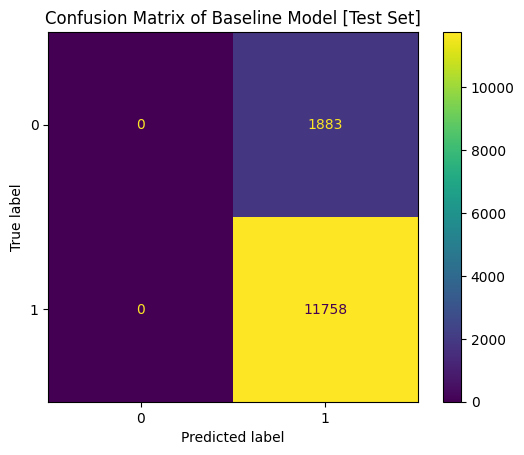

In [30]:
plot_confusion_matrix(base_model, "Baseline", X_test, Y_test)

### Build and Evaluate Logistic Regression Model

In [31]:
lg_model = LogisticRegression(max_iter=1000)

In [32]:
lg_pipeline = make_pipeline(preprocessor, lg_model)

Train the model

In [33]:
lg_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Evaluate the model

In [34]:
train_preds = lg_pipeline.predict(X_train)
train_preds[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [35]:
lg_train_errors = get_errors(lg_pipeline, X_train, Y_train)
lg_train_errors

{'accuracy': 0.8624184443955721,
 'recall': 0.9986816925366787,
 'precision': 0.8631760792457684,
 'f1': 0.9259978510099267}

Get cross validation result

In [36]:
cv_results = cross_validate(lg_pipeline, X_train, Y_train, cv=5, scoring=get_errors)

In [37]:
lg_avg_cv_errors = get_avg_cv_errors(cv_results)
lg_avg_cv_errors

{'accuracy': np.float64(0.8624184432030135),
 'recall': np.float64(0.9986816925366787),
 'precision': np.float64(0.8631762336095065),
 'f1': np.float64(0.9259978616552184)}

Evaluate the model on the test set

In [38]:
lg_test_errors = get_errors(lg_pipeline, X_test, Y_test)
lg_test_errors

{'accuracy': 0.8618869584341324,
 'recall': 0.9987242728355162,
 'precision': 0.8626946811636791,
 'f1': 0.9257390618841151}

#### Log errors

In [39]:
log_error("LG Model", lg_train_errors.values(), "train", perf_df)
log_error("LG Model", lg_avg_cv_errors.values(), "cv", perf_df)
log_error("LG Model", lg_test_errors.values(), "test", perf_df)

In [40]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739


### Plot LR model confusion matrix

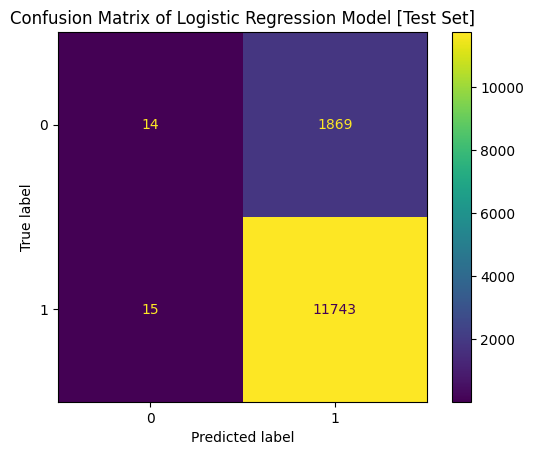

In [41]:
plot_confusion_matrix(lg_pipeline, "Logistic Regression", X_test, Y_test)

### Build and Evaluate Decision Tree Model

In [42]:
# Instantiate the model

dt_model = DecisionTreeClassifier(random_state=42)

In [43]:
# Create pipeline

dt_pipeline = make_pipeline(preprocessor, dt_model)
dt_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Handle the overfitting issue in the decision tree

In [44]:
dt_pipeline[-1].get_depth()

40

#### Find the optimal tree depth with grid search cv

In [45]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1_weighted'
}

In [46]:
param_grid = {"decisiontreeclassifier__max_depth": range(2, 40)}

grid_search_cv = GridSearchCV(
    dt_pipeline, param_grid=param_grid,
    scoring=scoring, refit="f1",
    return_train_score=True
)
grid_search_cv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'decisiontreeclassifier__max_depth': range(2, 40)}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1_weighted', 'precision': 'precision', 'recall': 'recall'}"
,n_jobs,None
,refit,'f1'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"


In [47]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,mean_test_f1,std_test_f1,rank_test_f1,split0_train_f1,split1_train_f1,split2_train_f1,split3_train_f1,split4_train_f1,mean_train_f1,std_train_f1
0,0.126776,0.009081,0.037714,0.007913,2,{'decisiontreeclassifier__max_depth': 2},0.861908,0.861908,0.861908,0.861908,...,0.798005,0.000045,15,0.798011,0.798011,0.798011,0.798011,0.797983,0.798005,0.000011
1,0.140103,0.011281,0.038844,0.005901,3,{'decisiontreeclassifier__max_depth': 3},0.861999,0.861908,0.861908,0.861358,...,0.804799,0.005599,10,0.809651,0.798011,0.798011,0.811625,0.811462,0.805752,0.006358
2,0.150551,0.015393,0.035025,0.003110,4,{'decisiontreeclassifier__max_depth': 4},0.862274,0.861816,0.862549,0.860808,...,0.806012,0.002908,9,0.808672,0.805624,0.801645,0.813752,0.808671,0.807673,0.003987
3,0.152930,0.009307,0.034066,0.007803,5,{'decisiontreeclassifier__max_depth': 5},0.862366,0.861083,0.862183,0.860991,...,0.806444,0.002853,6,0.808995,0.808969,0.802314,0.813960,0.809014,0.808650,0.003707
4,0.157861,0.013005,0.036331,0.004019,6,{'decisiontreeclassifier__max_depth': 6},0.861450,0.861358,0.861358,0.861266,...,0.806994,0.001848,4,0.810665,0.809117,0.808849,0.814402,0.809318,0.810470,0.002063
5,0.167509,0.009793,0.034988,0.004969,7,{'decisiontreeclassifier__max_depth': 7},0.861358,0.861450,0.861450,0.860533,...,0.806346,0.000979,7,0.812248,0.811672,0.809526,0.812623,0.812315,0.811677,0.001118
6,0.172099,0.007499,0.036772,0.007613,8,{'decisiontreeclassifier__max_depth': 8},0.860625,0.859250,0.859250,0.857326,...,0.806550,0.001189,5,0.815858,0.816025,0.815393,0.819360,0.813141,0.815955,0.001992
7,0.184425,0.011378,0.032967,0.002252,9,{'decisiontreeclassifier__max_depth': 9},0.857968,0.858884,0.856318,0.854852,...,0.807850,0.001805,3,0.819758,0.819184,0.825489,0.823815,0.820992,0.821848,0.002422
8,0.192965,0.010926,0.038249,0.007095,10,{'decisiontreeclassifier__max_depth': 10},0.853386,0.855219,0.855493,0.854119,...,0.808890,0.001404,1,0.831445,0.827680,0.830727,0.830352,0.827285,0.829498,0.001688
9,0.194312,0.004675,0.037598,0.003606,11,{'decisiontreeclassifier__max_depth': 11},0.851187,0.851187,0.849904,0.845872,...,0.808627,0.001786,2,0.838479,0.838289,0.840085,0.840476,0.837617,0.838989,0.001100


In [48]:
cv_cols = [
    "param_decisiontreeclassifier__max_depth",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_accuracy",
    "mean_test_precision",
    "std_test_recall",
    "mean_train_recall",
    "rank_test_f1",
    "std_test_f1",
    "std_train_recall",
    "rank_test_recall",
    "mean_test_accuracy",
    "mean_train_accuracy",
    "mean_test_precision",
    "mean_train_precision",
]

In [49]:
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_f1", "std_test_f1"])

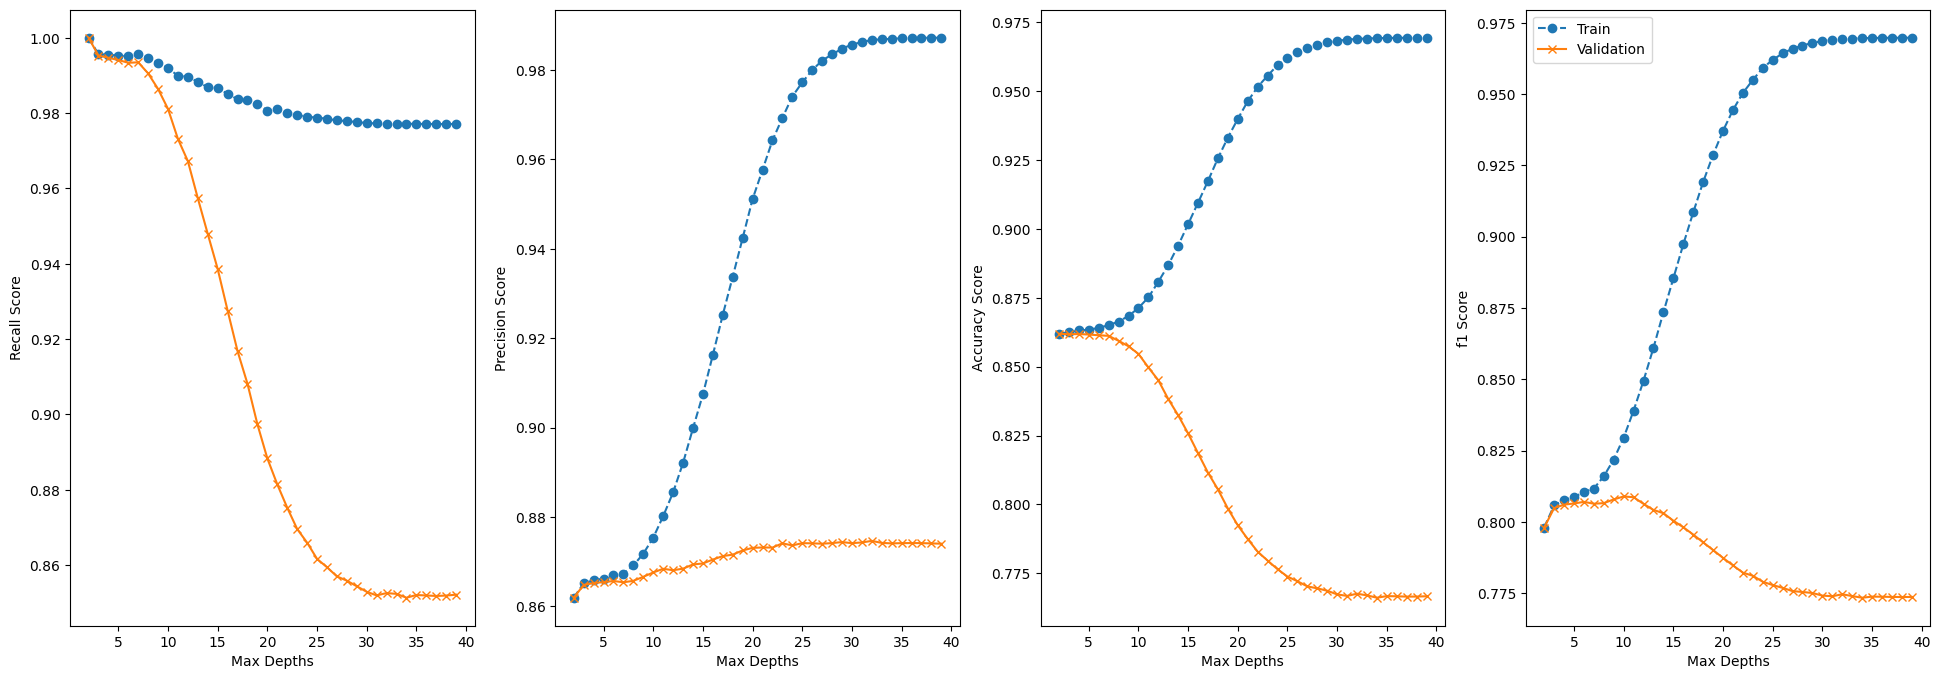

In [50]:
_, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 8))

ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_recall"],linestyle="--",marker="o",  label="Train")
ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_recall"], linestyle="-", marker="x", label="Validation")
ax1.set_xlabel("Max Depths")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_precision"], linestyle="--",marker="o",  label="Train")
ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_precision"], linestyle="-",marker="x", label="Validation")
ax2.set_xlabel("Max Depths")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_accuracy"], linestyle="--",marker="o", label="Train")
ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_accuracy"], linestyle="-",marker="x", label="Validation")
ax3.set_xlabel("Max Depths")
ax3.set_ylabel("Accuracy Score")

ax4.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_f1"], linestyle="--",marker="o", label="Train")
ax4.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_f1"], linestyle="-",marker="x", label="Validation")
ax4.set_xlabel("Max Depths")
ax4.set_ylabel("f1 Score")
plt.legend();

In [51]:
cv_results_subset.set_index("param_decisiontreeclassifier__max_depth").loc[[ 5 ,7,9,10, 13]]

,mean_test_recall,mean_test_f1,mean_test_accuracy,mean_test_precision,std_test_recall,mean_train_recall,rank_test_f1,std_test_f1,std_train_recall,rank_test_recall,mean_test_accuracy,mean_train_accuracy,mean_test_precision,mean_train_precision
param_decisiontreeclassifier__max_depth,,,,,,,,,,,,,,
5,0.994089,0.806444,0.861649,0.865414,0.002561,0.995216,6,0.002853,0.002315,4,0.861649,0.863371,0.865414,0.866205
7,0.993472,0.806346,0.861172,0.865385,0.000732,0.995737,7,0.000979,0.000846,5,0.861172,0.865025,0.865385,0.867314
9,0.986392,0.807850,0.857397,0.866604,0.002997,0.993408,3,0.001805,0.001408,8,0.857397,0.868370,0.866604,0.871771
10,0.981097,0.808890,0.854629,0.867575,0.001767,0.991931,1,0.001404,0.001748,9,0.854629,0.871293,0.867575,0.875349
13,0.957389,0.804163,0.838245,0.868424,0.001179,0.988279,11,0.001069,0.001191,12,0.838245,0.886839,0.868424,0.892074


#### Retrain the model with max_depth of 10

In [52]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

In [53]:
dt_pipeline = make_pipeline(preprocessor, dt_model)
dt_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [54]:
dt_train_errors = get_errors(dt_pipeline, X_train, Y_train)
dt_train_errors

{'accuracy': 0.8699508833663221,
 'recall': 0.9932596215181799,
 'precision': 0.8732707694608539,
 'f1': 0.9294084876942361}

#### Cross validate

In [55]:
# cv_results = cross_validate(dt_pipeline, X_train, Y_train, cv=5, scoring=scoring, n_jobs=-1)
# dt_avg_cv_errors = get_avg_cv_errors(cv_results)
# dt_avg_cv_errors

#### Evaluate on test

In [56]:
dt_test_errors = get_errors(dt_pipeline, X_test, Y_test)
dt_test_errors

{'accuracy': 0.856315519390074,
 'recall': 0.9853716618472529,
 'precision': 0.8663077613279497,
 'f1': 0.9220117778131466}

#### Log errors

In [57]:
log_error("DT Model", dt_train_errors.values(), "train", perf_df)
# log_error("DT Model", dt_avg_cv_errors.values(), "cv", perf_df)
log_error("DT Model", dt_test_errors.values(), "test", perf_df)

In [58]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739
DT Model,0.869951,0.99326,0.873271,0.929408,NaN,NaN,NaN,NaN,0.856316,0.985372,0.866308,0.922012


### Plot DT model confusion matrix

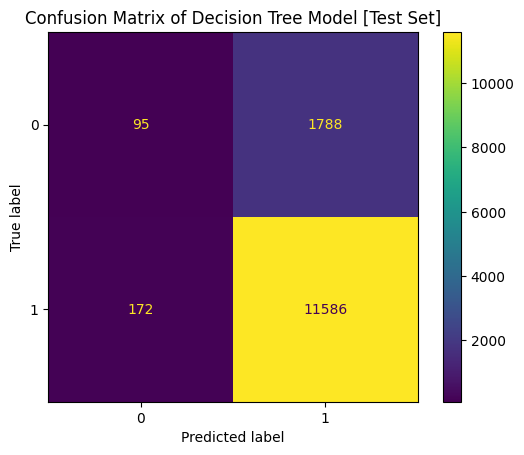

In [59]:
plot_confusion_matrix(dt_pipeline, "Decision Tree", X_test, Y_test)

## Random Forest

In [60]:
rf_model = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")

In [61]:
rf_pipeline = make_pipeline(preprocessor, rf_model)
rf_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [62]:
rf_train_errors = get_errors(rf_pipeline, X_train, Y_train)
rf_train_errors

{'accuracy': 0.7369327761894289,
 'recall': 0.7495853710397619,
 'precision': 0.9318794607454401,
 'f1': 0.8308508131039359}

### Evaluate on cross val set

In [63]:
# rf_cv_results = cross_validate(rf_pipeline, X_train, Y_train, scoring=scoring, cv=5)
# rf_avg_cv_errors = get_avg_cv_errors(rf_cv_results)
# rf_avg_cv_errors

#### evaluate on test set

In [64]:
rf_test_errors = get_errors(rf_pipeline, X_test, Y_test)
rf_test_errors

{'accuracy': 0.7110182537937101,
 'recall': 0.735414186086069,
 'precision': 0.9123232749525216,
 'f1': 0.8143718214352985}

#### Log errors

In [65]:
log_error("RF Model", rf_train_errors.values(), "train", perf_df)
# log_error("RF Model", rf_avg_cv_errors.values(), "cv", perf_df)
log_error("RF Model", rf_test_errors.values(), "test", perf_df)

In [66]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739
DT Model,0.869951,0.99326,0.873271,0.929408,NaN,NaN,NaN,NaN,0.856316,0.985372,0.866308,0.922012
RF Model,0.736933,0.749585,0.931879,0.830851,NaN,NaN,NaN,NaN,0.711018,0.735414,0.912323,0.814372


### Plot RF model confusion matrix

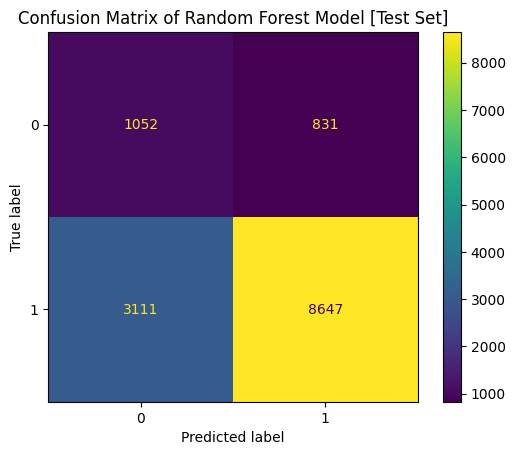

In [67]:
plot_confusion_matrix(rf_pipeline, "Random Forest", X_test, Y_test)

### Gradient Boosting

In [68]:
gb_model = GradientBoostingClassifier(max_depth=10, random_state=42)

In [69]:
gb_pipeline = make_pipeline(preprocessor, gb_model)
gb_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [70]:
gb_train_errors = get_errors(gb_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 0.9029763213840627,
 'recall': 0.9975122262385712,
 'precision': 0.900614321366865,
 'f1': 0.946589991928975}

#### Evaluate with cross validation

In [71]:
# gb_cv_results = cross_validate(gb_pipeline, X_train, Y_train, scoring=scoring, cv=5)
# gb_avg_cv_errors = get_avg_cv_errors(gb_cv_results)
# gb_avg_cv_errors

#### Evaluate on test

In [72]:
gb_test_errors = get_errors(gb_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.8561689025731252,
 'recall': 0.9806089470998469,
 'precision': 0.869270205066345,
 'f1': 0.9215890016785229}

#### Log errors

In [73]:
log_error("GB Model", gb_train_errors.values(), "train", perf_df)
# log_error("GB Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("GB Model", gb_test_errors.values(), "test", perf_df)

In [74]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739
DT Model,0.869951,0.99326,0.873271,0.929408,NaN,NaN,NaN,NaN,0.856316,0.985372,0.866308,0.922012
RF Model,0.736933,0.749585,0.931879,0.830851,NaN,NaN,NaN,NaN,0.711018,0.735414,0.912323,0.814372
GB Model,0.902976,0.997512,0.900614,0.94659,NaN,NaN,NaN,NaN,0.856169,0.980609,0.86927,0.921589


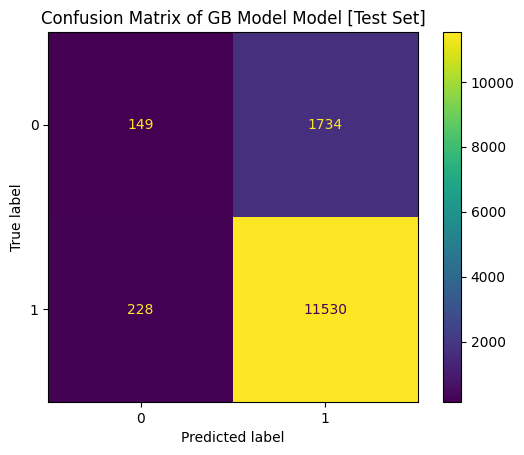

In [75]:
plot_confusion_matrix(gb_pipeline, "GB Model", X_test, Y_test)

### find optimal error 

In [76]:
sample_weights = compute_sample_weight(class_weight="balanced" , 
                                       y=Y_train)

In [77]:
param_grid = {"gradientboostingclassifier__learning_rate": [0.005,0.01,0.02], 
              "gradientboostingclassifier__n_estimators": [100,200,300] }
 

grid_search_cv = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring={"accuracy": "accuracy" , "precision": "precision_weighted", "recall": "recall_weighted" , "f1": "f1_weighted"},
    return_train_score=True,
    refit="f1",
    n_jobs=-1,
)


In [78]:
grid_search_cv.fit(X_train, Y_train , gradientboostingclassifier__sample_weight = sample_weights)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'gradientboostingclassifier__learning_rate': [0.005, 0.01, ...], 'gradientboostingclassifier__n_estimators': [100, 200, ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1_weighted', 'precision': 'precision_weighted', 'recall': 'recall_weighted'}"
,n_jobs,-1
,refit,'f1'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"


In [79]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)

In [80]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "param_gradientboostingclassifier__n_estimators",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_accuracy",
    "mean_test_f1",
    "rank_test_f1",
    "mean_train_recall",
    
    "rank_test_recall",
    
    "mean_train_accuracy",
    
    "mean_train_precision",
]
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_f1"])

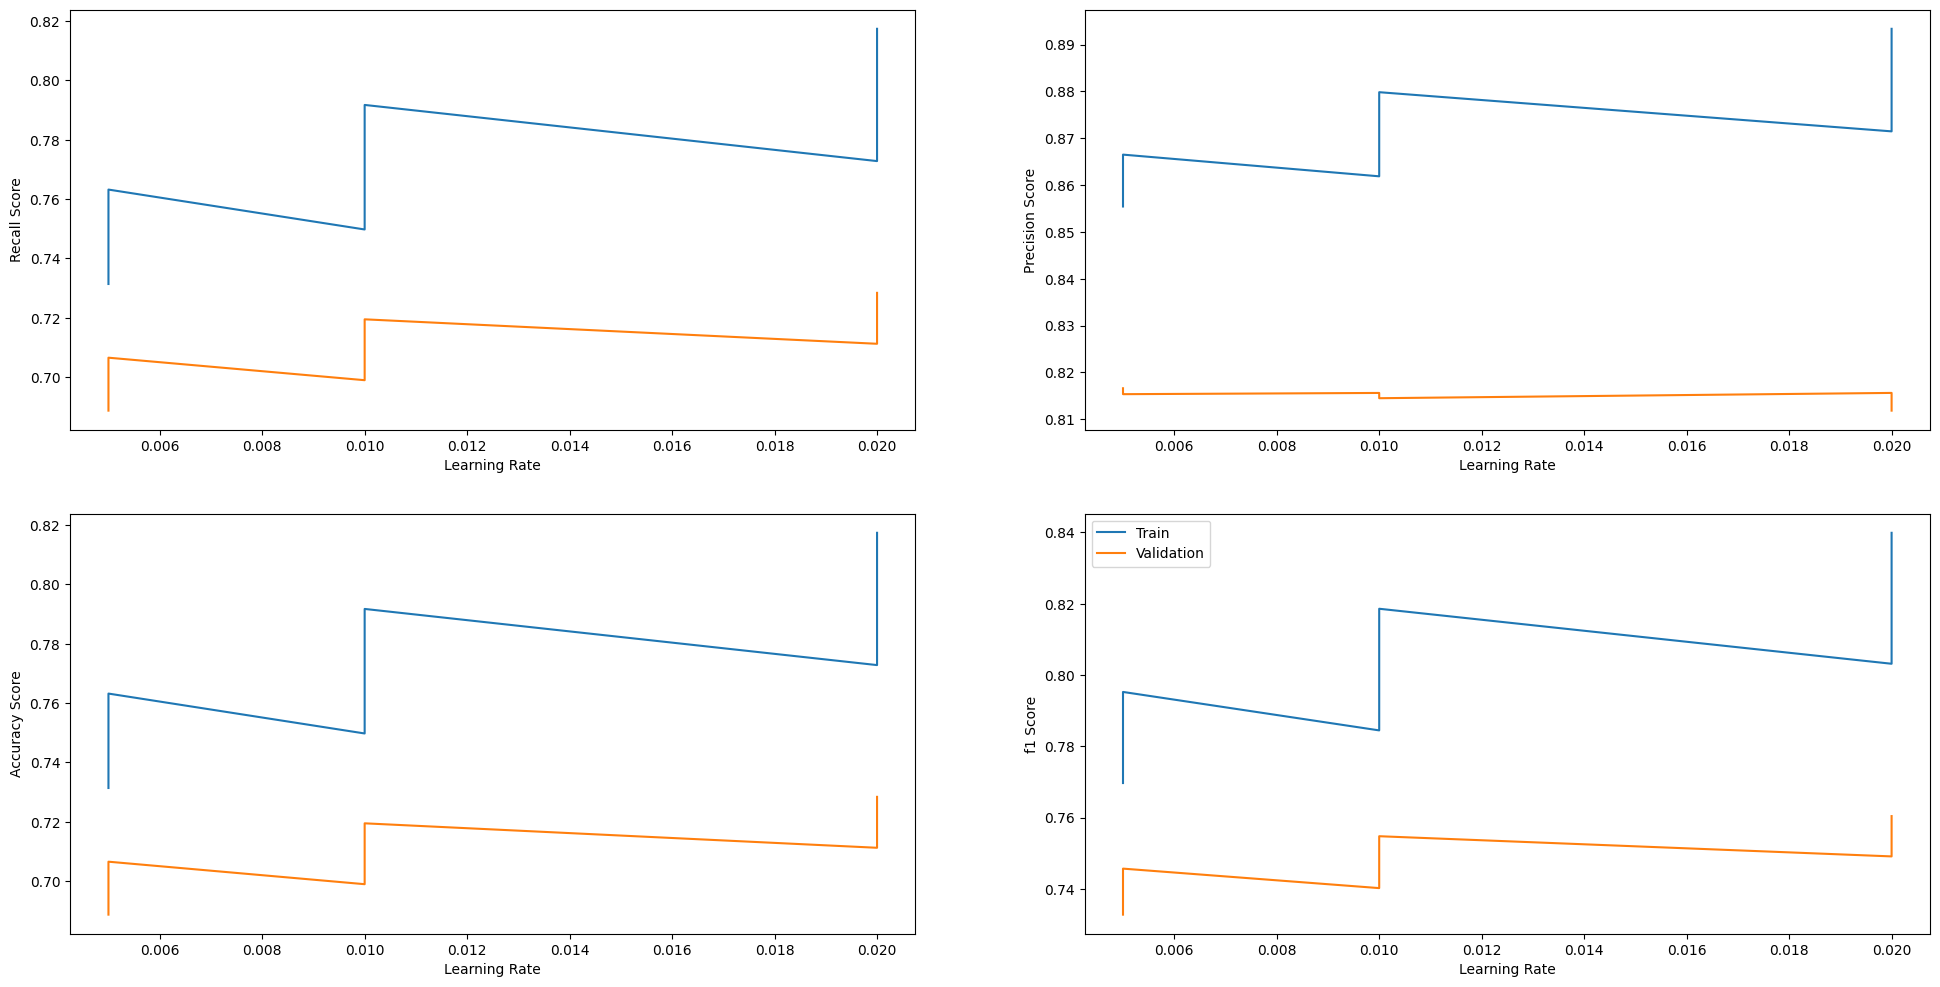

In [81]:
fig, axs = plt.subplots(2, 2, figsize=(24, 12))

axs[0,0].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_recall"], label="Train")
axs[0,0].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_recall"], label="Validation")
axs[0,0].set_xlabel("Learning Rate")
axs[0,0].set_ylabel("Recall Score")

axs[0,1].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_precision"], label="Train")
axs[0,1].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_precision"], label="Validation")
axs[0,1].set_xlabel("Learning Rate")
axs[0,1].set_ylabel("Precision Score")

axs[1,0].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_accuracy"], label="Train")
axs[1,0].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_accuracy"], label="Validation")
axs[1,0].set_xlabel("Learning Rate")
axs[1,0].set_ylabel("Accuracy Score")

axs[1,1].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_f1"], label="Train")
axs[1,1].plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_f1"], label="Validation")
axs[1,1].set_xlabel("Learning Rate")
axs[1,1].set_ylabel("f1 Score")
plt.legend();

In [82]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")

,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__n_estimators,mean_test_recall,mean_test_precision,mean_test_accuracy,mean_test_f1,rank_test_f1,mean_train_recall,rank_test_recall,mean_train_accuracy,mean_train_precision
1,0.005,200,0.699417,0.815509,0.699417,0.740581,7,0.750005,7,0.750005,0.861784
2,0.005,300,0.706528,0.815348,0.706528,0.745714,6,0.763218,6,0.763218,0.866502
0,0.005,100,0.688677,0.816609,0.688677,0.732811,9,0.731380,9,0.731380,0.855425
4,0.010,200,0.711440,0.815252,0.711440,0.749248,4,0.773124,4,0.773124,0.871124
3,0.010,100,0.698941,0.815610,0.698941,0.740249,8,0.749762,8,0.749762,0.861869
5,0.010,300,0.719467,0.814486,0.719467,0.754804,3,0.791758,3,0.791758,0.879832
8,0.020,300,0.728392,0.811833,0.728392,0.760448,1,0.817425,1,0.817425,0.893367
7,0.020,200,0.722967,0.813272,0.722967,0.757001,2,0.801815,2,0.801815,0.885447
6,0.020,100,0.711220,0.815617,0.711220,0.749142,5,0.772822,5,0.772822,0.871468


### Retrain model using learning rate of 0.005

In [83]:
gb_model_pretrain = GradientBoostingClassifier(max_depth=10, learning_rate=0.02, n_estimators=300,  random_state=42)

In [84]:
gb_pipeline_pretrain = make_pipeline(preprocessor, gb_model_pretrain)
gb_pipeline_pretrain.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evalaute on train set 

In [85]:
gb_pretrain_errors = get_errors(gb_pipeline_pretrain, X_train, Y_train)
gb_pretrain_errors

{'accuracy': 0.8928964152188256,
 'recall': 0.9977673825217946,
 'precision': 0.8910261279052104,
 'f1': 0.9413806247116175}

#### Cross Validate 

In [86]:
# pretrain_cv_results = cross_validate(gb_pipeline_pretrain, X_train, Y_train, scoring=["accuracy", "precision", "recall", "f1"], cv=5)
# pre_gb_avg_cv_errors = get_avg_cv_errors(pretrain_cv_results)
# pre_gb_avg_cv_errors

#### Test set 

In [87]:
pretrain_gb_test_errors = get_errors(gb_pipeline_pretrain, X_test, Y_test)
pretrain_gb_test_errors

{'accuracy': 0.8569019866578697,
 'recall': 0.9840959346827691,
 'precision': 0.8676514697060588,
 'f1': 0.9222124810711724}

In [88]:
log_error("preOpt GB Model", gb_pretrain_errors.values(), "train", perf_df)
# log_error("preOpt GB Model", pre_gb_avg_cv_errors.values(), "cv", perf_df)
log_error("preOpt GB Model", pretrain_gb_test_errors.values(), "test", perf_df)

In [89]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739
DT Model,0.869951,0.99326,0.873271,0.929408,NaN,NaN,NaN,NaN,0.856316,0.985372,0.866308,0.922012
RF Model,0.736933,0.749585,0.931879,0.830851,NaN,NaN,NaN,NaN,0.711018,0.735414,0.912323,0.814372
GB Model,0.902976,0.997512,0.900614,0.94659,NaN,NaN,NaN,NaN,0.856169,0.980609,0.86927,0.921589
preOpt GB Model,0.892896,0.997767,0.891026,0.941381,NaN,NaN,NaN,NaN,0.856902,0.984096,0.867651,0.922212


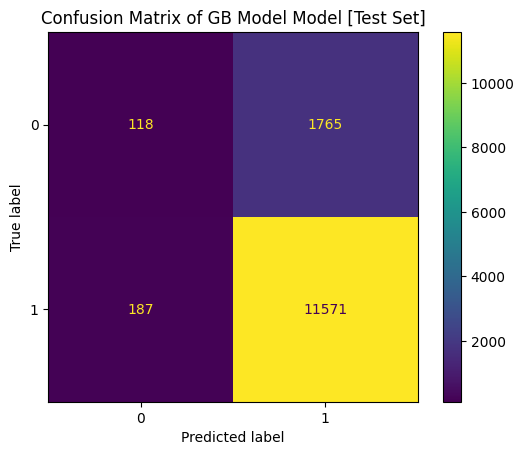

In [90]:
plot_confusion_matrix(gb_pipeline_pretrain, "GB Model", X_test, Y_test)

#### Add kmeans features to GB model

In [91]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

In [92]:
kmean_pipe = make_pipeline(
    preprocessor,
    StandardScaler(),
    KMeans(3, random_state=42)
)

In [93]:
feat_union = FeatureUnion(
    [
        ("base_feat", preprocessor),
        ("kmeans_feat", kmean_pipe),
    ],
    verbose_feature_names_out=False
)

In [94]:
gb_kmeans_pipeline = make_pipeline(
    feat_union,
    gb_model_pretrain
)

In [95]:
gb_kmeans_pipeline.fit(X_train, Y_train)

,steps,"[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'median'


#### Evaluate the training set

In [96]:
gb_km_train_errors = get_errors(gb_kmeans_pipeline, X_train, Y_train)
gb_km_train_errors

{'accuracy': 0.89230994795103,
 'recall': 0.9987667446310865,
 'precision': 0.8897897329039591,
 'f1': 0.9411340412742937}

#### Evaluate with cross validation

In [97]:
# cv_results = cross_validate(gb_kmeans_pipeline, X_train, Y_train, scoring=scoring, cv=5, n_jobs=-1)
# gb_avg_cv_errors = get_avg_cv_errors(cv_results)
# gb_avg_cv_errors

#### Evaluate on test

In [98]:
gb_test_errors = get_errors(gb_kmeans_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.8590279305036288,
 'recall': 0.9872427283551625,
 'precision': 0.8674986921754727,
 'f1': 0.9235053104737658}

In [99]:
log_error("GB+KM Model", gb_train_errors.values(), "train", perf_df)
# log_error("GB+KM Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("GB+KM Model", gb_test_errors.values(), "test", perf_df)

In [100]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739
DT Model,0.869951,0.99326,0.873271,0.929408,NaN,NaN,NaN,NaN,0.856316,0.985372,0.866308,0.922012
RF Model,0.736933,0.749585,0.931879,0.830851,NaN,NaN,NaN,NaN,0.711018,0.735414,0.912323,0.814372
GB Model,0.902976,0.997512,0.900614,0.94659,NaN,NaN,NaN,NaN,0.856169,0.980609,0.86927,0.921589
preOpt GB Model,0.892896,0.997767,0.891026,0.941381,NaN,NaN,NaN,NaN,0.856902,0.984096,0.867651,0.922212
GB+KM Model,0.902976,0.997512,0.900614,0.94659,NaN,NaN,NaN,NaN,0.859028,0.987243,0.867499,0.923505


## Plot Confusion Matrix of GB_KM model

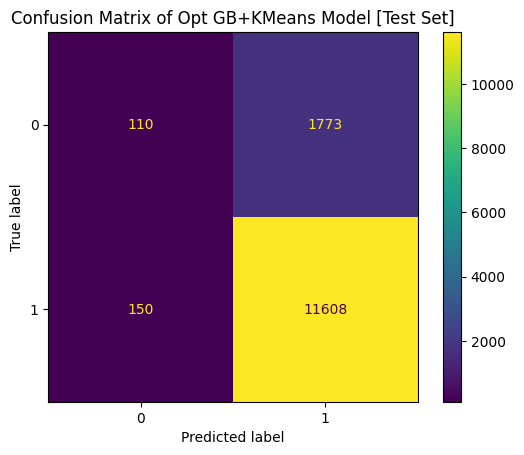

In [101]:
plot_confusion_matrix(gb_kmeans_pipeline, "Opt GB+KMeans", X_test, Y_test)

#### Handle Class imbalance 

## Manuel threshold tuning

In [102]:
y_proba = gb_kmeans_pipeline.predict_proba(X_train)[:,1]

In [103]:
thresholds = np.linspace(0.1, 0.9,50)

results = []
for t in thresholds:
    y_pred = (y_proba >= t ).astype(int)

    precision = precision_score(Y_train, y_pred)
    recall = recall_score(Y_train, y_pred)
    accuracy = accuracy_score(Y_train, y_pred)
    f1 = f1_score(Y_train,y_pred)

    results.append((t, precision, recall ,accuracy ,  f1))

df_thresh = pd.DataFrame(results, columns=["threshold", "precision", "recall",  "accuracy" , "f1"])

In [104]:
best = df_thresh.sort_values("f1", ascending=False).iloc[0]
best

threshold    0.655102
precision    0.919517
recall       0.984839
accuracy     0.912635
f1           0.951058
Name: 34, dtype: float64

In [105]:
best_threshold = best["threshold"]

y_test_proba = gb_kmeans_pipeline.predict_proba(X_test)[:,1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

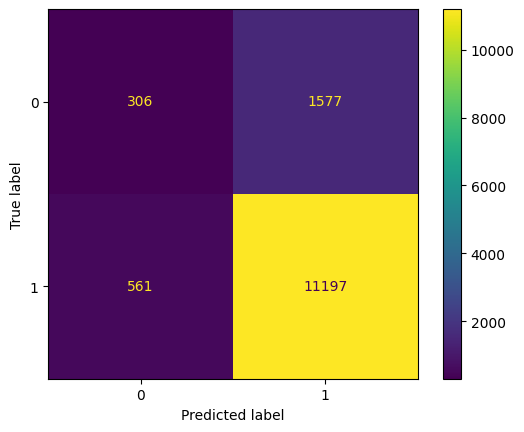

In [106]:
ConfusionMatrixDisplay.from_predictions(Y_test,y_test_pred)

In [107]:
from sklearn.metrics import precision_recall_curve

In [108]:
precision, recall, thresholds= precision_recall_curve(Y_test,y_test_proba)

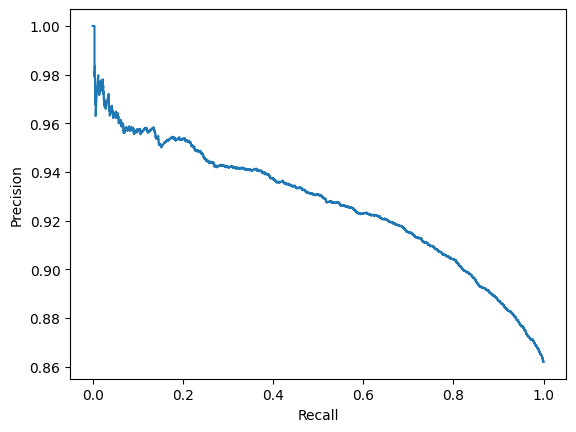

In [109]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision");

## Visualize feature importance

In [110]:
feat_imps = pd.Series(
    gb_kmeans_pipeline[-1].feature_importances_,
    index=gb_kmeans_pipeline[-1].feature_names_in_,
).sort_values()

In [111]:
def clean_feats_name(feature):
    if "__" in feature:
        return feature[feature.index("__")+2:]
    return feature

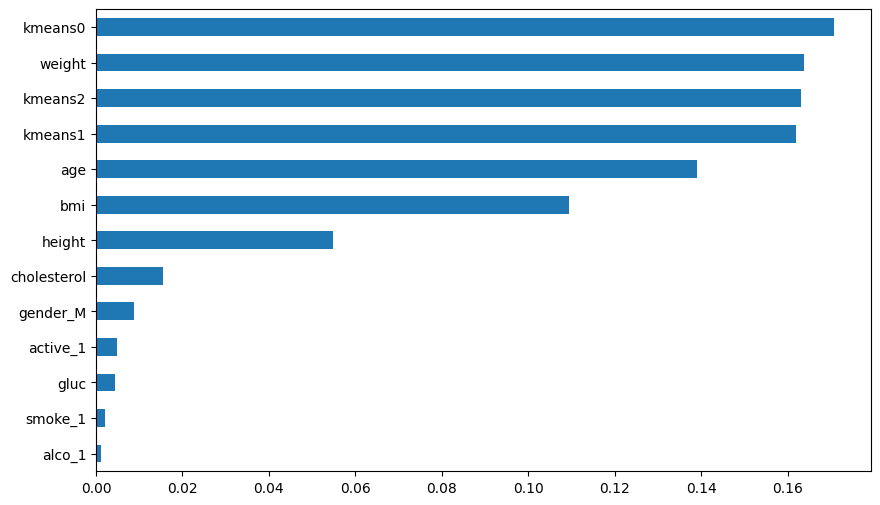

In [112]:
ax = feat_imps.plot(kind="barh", figsize=(10, 6))
ax.set_yticklabels(feat_imps.index.map(clean_feats_name));

## Find optimal probality threshold 

In [133]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [134]:
ttcv = TunedThresholdClassifierCV(gb_kmeans_pipeline, cv=5, n_jobs=-1)
ttcv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,scoring,'balanced_accuracy'
,response_method,'auto'
,thresholds,100
,cv,5
,refit,True
,n_jobs,-1
,random_state,None
,store_cv_results,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None


### Get the error 

In [135]:
ttcv_train_error = get_errors(ttcv,X_train,Y_train)
ttcv_train_error

{'accuracy': 0.725753243897075,
 'recall': 0.695619817137997,
 'precision': 0.9805478959357391,
 'f1': 0.8138667064706321}

#### Evaluate with cross validation

In [ ]:
# ttcv_results = cross_validate(
#     ttcv, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1
# )


In [ ]:
# ttcv_cv_errors = get_avg_cv_errors(ttcv_results)
# ttcv_cv_errors

#### test set 

In [136]:
ttcv_test_error = get_errors(ttcv, X_test, Y_test)
ttcv_test_error

{'accuracy': 0.6378564621362071,
 'recall': 0.6336962068378976,
 'precision': 0.9216971796140524,
 'f1': 0.7510331619796391}

#### Plot confusion matrix 

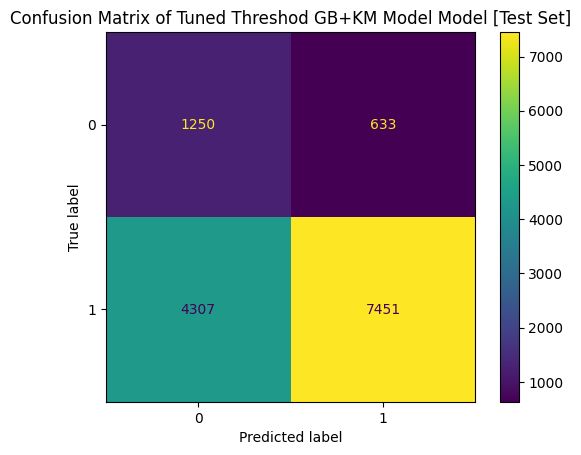

In [137]:
plot_confusion_matrix(
    ttcv, "Tuned Threshod GB+KM Model", X_test, Y_test
)

In [224]:
log_error("Opt GB+KM+TTCV Model", ttcv_train_error.values(), "train", perf_df)
# log_error("Opt GB+KM+TTCV Model", ttcv_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_test_error.values(), "test", perf_df)

In [225]:
perf_df

,train_accuracy,train_recall,train_precision,train_f1,cv_accuracy,cv_recall,cv_precision,cv_f1,test_accuracy,test_recall,test_precision,test_f1
Base Model,0.861924,1.0,0.861924,0.925842,0.861924,1.0,0.861924,0.925842,0.86196,1.0,0.86196,0.925863
LG Model,0.862418,0.998682,0.863176,0.925998,0.862418,0.998682,0.863176,0.925998,0.861887,0.998724,0.862695,0.925739
DT Model,0.869951,0.99326,0.873271,0.929408,0.854629,0.981097,0.867575,0.80889,0.856316,0.985372,0.866308,0.922012
RF Model,0.867367,0.997831,0.868024,0.928412,0.862418,0.995301,0.865311,0.806488,0.86284,0.996003,0.865238,0.926027
GB Model,0.902976,0.997512,0.900614,0.94659,0.853457,0.977185,0.869081,0.811245,0.856169,0.980609,0.86927,0.921589
preOpt GB Model,0.883916,0.998108,0.882582,0.936797,0.858771,0.987327,0.867212,0.92338,0.859981,0.989199,0.867079,0.924122
GB+KM Model,0.902976,0.997512,0.900614,0.94659,0.858973,0.987689,0.867157,0.809523,0.860201,0.989964,0.866781,0.924286
Opt GB+KM+TTCV Model,0.714317,0.690899,0.968668,0.806538,NaN,NaN,NaN,NaN,0.643208,0.640415,0.921777,0.755759


### looks like the manual threshlod tuning is best , so i will be going for the manual tuning

### Retrain the whole dataset 

In [113]:
full_sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y
)
gb_kmeans_pipeline.fit(x,y, gradientboostingclassifier__sample_weight = full_sample_weight)

,steps,"[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'median'


## wrap model with threshold

In [202]:
class ThresholdClassifier: 
    def __init__(self , model,  threshold):
        self.model = model 
        self.threshold = threshold

    def predict(self ,  x):
        proba = self.model.predict_proba(x)[:,1]
        return (proba >= self.threshold).astype(int)
    
    def predict_proba(self , x):
        return self.model.predict_proba(x)
        

In [203]:
y_full_proba = gb_kmeans_pipeline.predict_proba(x)[:,1]
precision, recall, thresholds = precision_recall_curve(y,y_full_proba)
f1_scores = 2 * (precision * recall) / (precision +recall +1e-8)

best_index = np.argmax(f1_scores)
best_threshold_new = thresholds[best_index]

In [211]:
for t in [0.3,0.4,0.5,0.6]:
    preds = (y_full_proba >= t ).astype(int)
    print(t, f1_score(y, preds) , precision_score(y ,preds) , recall_score(y , preds))

0.3 0.9328513255214826 0.9119788112183549 0.9547016397904334
0.4 0.9181879177086691 0.9412594908441269 0.8962203170715112
0.5 0.8769571200119007 0.967048064304462 0.802221541811254
0.6 0.7932400101807076 0.9878540456931308 0.6626862625025516


In [224]:
final_model = ThresholdClassifier(
    model=gb_kmeans_pipeline , 
    threshold=0.3
)

In [227]:
def get_errors(model, X, y):
    

    preds = model.predict(X)
    accuracy = accuracy_score(y, preds )
    recall = recall_score(y, preds )
    precision = precision_score(y, preds, zero_division=0.0 )
    f1 = f1_score(y,preds)
    return {"accuracy": accuracy, "recall": recall, "precision": precision ,"f1" : f1}

In [238]:
get_errors(final_model,X_test,Y_test)

{'accuracy': 0.8816802287222344,
 'recall': 0.955859840108862,
 'precision': 0.911221015080266,
 'f1': 0.9330068072389175}

In [239]:
ypre = final_model.predict(X_test)

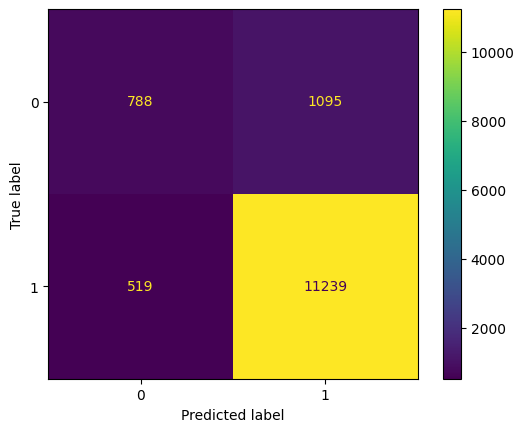

In [240]:
ConfusionMatrixDisplay.from_predictions(Y_test, ypre)

## Save Model

In [241]:
import joblib

In [242]:
joblib.dump(final_model,"../../models/hyper_basic_model_v1.pkl")

['../../models/hyper_basic_model_v1.pkl']

#### Load Model

In [243]:
model = joblib.load("../../models/hyper_basic_model_v1.pkl")

In [244]:
get_errors(model,x,y)

{'accuracy': 0.8815336119052856,
 'recall': 0.9547016397904334,
 'precision': 0.9119788112183549,
 'f1': 0.9328513255214826}

In [235]:
df.iloc[50:60]

,gender,height,weight,cholesterol,gluc,smoke,alco,active,age,bmi,bp_binary
50,F,160,75.0,1,1,0,0,0,49,29.296875,0
51,F,169,84.0,1,1,0,0,1,50,29.410735,1
52,M,166,85.0,1,1,0,0,1,53,30.846277,1
53,F,165,77.0,3,3,0,0,1,39,28.282828,1
54,F,152,79.0,1,1,0,0,1,53,34.193213,1
55,M,165,73.0,1,1,0,0,0,59,26.813590,1
56,F,171,76.0,1,2,0,0,1,47,25.990903,0
57,F,165,90.0,1,1,0,0,0,62,33.057851,1
58,M,172,84.0,1,1,1,0,1,43,28.393726,1
59,F,164,64.0,1,1,1,0,1,55,23.795360,1


In [236]:
pd.DataFrame(model.predict(x.iloc[50:60]))

,0
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1
